In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

In [2]:
# -----------------------------
# 1. Load hidden vectors and metadata
# -----------------------------
hidden = np.load("./vectors/vec_E480_L2.npy")       # shape: (num_samples, 2)
meta = pd.read_csv("./vectors/meta_E480_L2.csv")       # must include a column 'tone' (e.g., T2/T3)

labels = meta['consonant'].astype('category').cat.codes.values  # convert to integer labels

In [4]:
# -----------------------------
# 2. Compute Euclidean silhouette on raw hidden vectors
# -----------------------------
sil_euc_raw = silhouette_score(hidden, labels, metric='euclidean')

# -----------------------------
# 3. Compute cosine silhouette on raw hidden vectors
# -----------------------------
sil_cos_raw = silhouette_score(hidden, labels, metric='cosine')

# -----------------------------
# 4. Compute Euclidean silhouette on unit-normalized vectors
#    (magnitude removed, only direction)
# -----------------------------
hidden_unit = normalize(hidden, axis=1)  # row-wise normalization to unit length
sil_euc_unit = silhouette_score(hidden_unit, labels, metric='euclidean')

In [5]:
# -----------------------------
# 5. Inspect vector norms per category
# -----------------------------
norms = np.linalg.norm(hidden, axis=1)
norm_df = pd.DataFrame({'consonant': meta['consonant'], 'norm': norms})
norm_stats = norm_df.groupby('consonant')['norm'].agg(['mean', 'std'])

# -----------------------------
# 6. Print results
# -----------------------------
print("Silhouette scores:")
print(f"Euclidean (raw): {sil_euc_raw:.3f}")
print(f"Cosine (raw):    {sil_cos_raw:.3f}")
print(f"Euclidean (unit vectors): {sil_euc_unit:.3f}")
print("\nVector norm stats per category:")
print(norm_stats)

Silhouette scores:
Euclidean (raw): 0.769
Cosine (raw):    0.677
Euclidean (unit vectors): 0.666

Vector norm stats per category:
               mean       std
consonant                    
sh         1.683912  0.454048
tsh        4.588402  0.609004


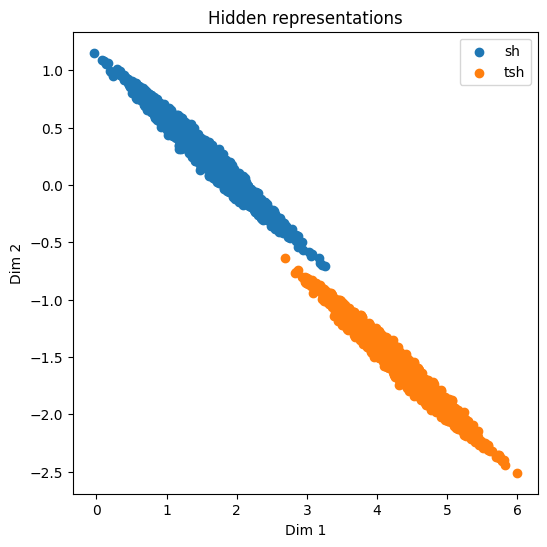

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
for tone, color in zip(['sh','tsh'], ['blue','red']):
    idx = meta['consonant'] == tone
    plt.scatter(hidden[idx,0], hidden[idx,1], label=tone)
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.title("Hidden representations")
plt.legend()
plt.show()